Librerías y Funciones propias:

In [ ]:
import sys
import os
sys.path.append(os.path.abspath('..')) 

import numpy as np
import matplotlib.pyplot as plt
from helpers.room import room
from helpers.generateRirs import generateRirs

Simulation:

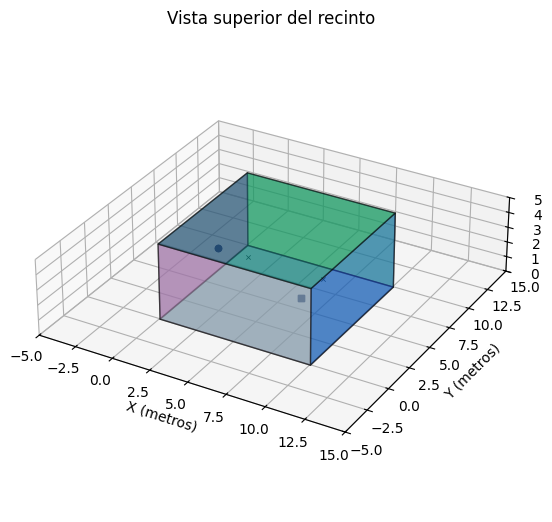

In [ ]:
fs = 48000
room = room(fs)

Obtain RIRs:

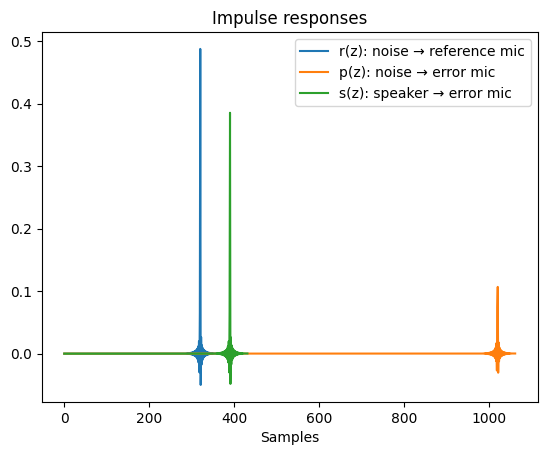

Delay R: 6.666666666666667 ms
Delay P: 21.25 ms
Delay S: 8.125 ms
In order to comply with causality, computational time must be smaller than: 6.458333333333332 ms
362
1062
432


In [ ]:
rir_r, rir_p, rir_s = generateRirs(fs, room)

FxLMS (Esta implementación es mas simple y utiliza len(w) = len(s) = len(p), no es realista)


In [ ]:
# Nota: esta implementación no funciona si no se paddean las rirs de la siguiente forma (no es necesario para la siguiente implementación)
rirs = [rir_r, rir_p, rir_s]
max_len = max(len(r) for r in rirs)
rirs_padded = [np.pad(r, (0, max_len - len(r)), 'constant') for r in rirs]

rir_r, rir_p, rir_s = rirs_padded


np.random.seed(0)

N = 100000
t = np.arange(N) * (1/fs)

L = len(rir_r)
mu = 5e-4
x = np.random.randn(N)

# Adaptive filter initialization
w = np.zeros(L)

# Primary path
p = rir_p

# Secondary path
s = rir_s

# Filtered X output initialization
f_x_hist = np.zeros(N)

# Adaptive filter output initilization
y_hist = np.zeros(N)

# History
e_hist = np.zeros(N)
w_hist = np.zeros((N, L))

for n in range(L, N):
    # Entry vector (a slice of x)
    x_vec = x[n : n - L : -1]

    # Desired signal
    d = np.dot(p, x_vec)

    # Filter output with secondary path
    y_hist[n] = np.dot(w, x_vec)
    y_vec = y_hist[n : n - L : -1]
    y_f = np.dot(s, y_vec)

    # Error signal
    e = d - y_f
    e_hist[n] = e

    # Filtered X
    f_x_hist[n] = np.dot(s, x_vec)
    f_x_vec = f_x_hist[n: n - L: -1]

    # LMS algorithm
    w = w + mu*f_x_vec*e
    w_hist[n, :] = w

plt.figure()
plt.stem(p, linefmt='C0-', markerfmt='C0o', basefmt=" ")
plt.stem(np.convolve(w, s)[:L], linefmt='C1-', markerfmt='C1s', basefmt=" ")
plt.legend(['Primary path p', 'Adaptive filter w'])
plt.title('Final coefficients')
plt.show()

plt.figure()
plt.plot(t, 10*np.log10(e_hist**2 + 1e-12))
plt.title('Error power')
plt.xlabel('Time [s]')
plt.ylabel('Power [dB]')
plt.show()

plt.figure()
for k in range(L):
    plt.plot(t, w_hist[:, k])
plt.title('Coefficient convergence')
plt.xlabel('Time [s]')
plt.ylabel('Value')
plt.show()

FxLMS por muestra

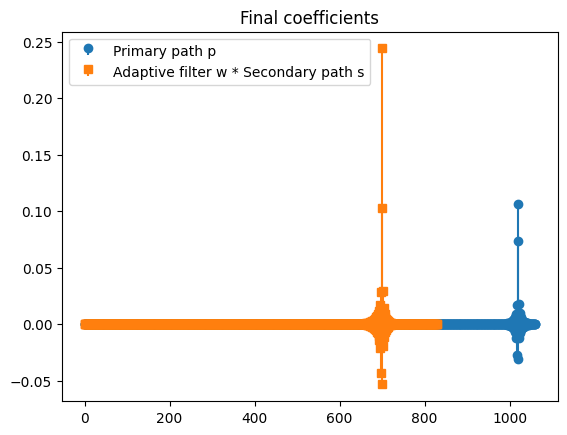

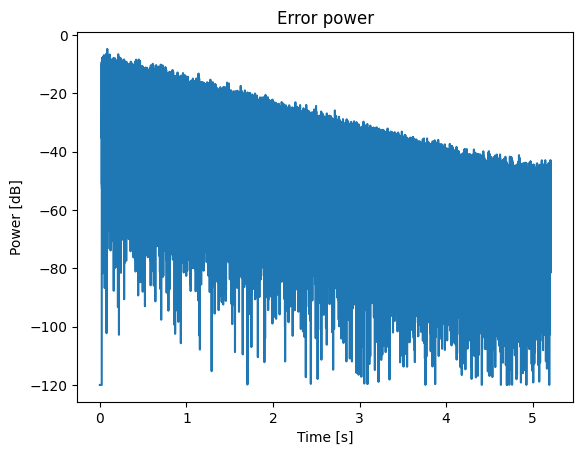

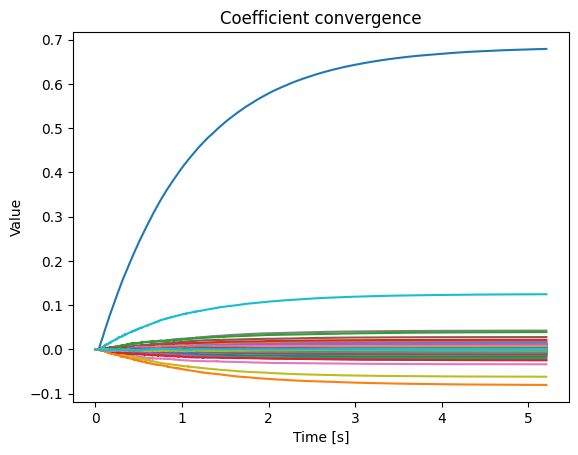

In [80]:
np.random.seed(0)

N = 250000
t = np.arange(N) * (1/fs)

Lw = 400
mu = 5e-4
x = np.random.randn(N)

# Adaptive filter initialization
w = np.zeros(Lw)

# Primary path
p = rir_p

# Secondary path
s = rir_s

# Noise source path
r = rir_r

# Reference mic output initialization
r_x_hist = np.zeros(N)

# Filtered X output initialization
f_x_hist = np.zeros(N)

# Adaptive filter output initilization
y_hist = np.zeros(N)

# History
e_hist = np.zeros(N)
w_hist = np.zeros((N, Lw))


for n in range(max(Lw, len(p), len(s), len(r)), N):
    # Primary path P(z)
    x_p_vec = x[n : n - len(p) : -1]
    d = np.dot(p, x_p_vec)

    # Reference mic signal
    x_r_vec = x[n : n - len(r) : -1]
    r_x_hist[n] = np.dot(x_r_vec, r)

    # Adaptive filter W(z) + secondary path S(z)
    x_w_vec = r_x_hist[n : n - Lw : -1]
    y_hist[n] = np.dot(w, x_w_vec)

    y_s_vec = y_hist[n : n - len(s) : -1]
    y_f = np.dot(s, y_s_vec)

    # Error signal
    e = d - y_f
    e_hist[n] = e

    # Filtered X
    x_shat_vec = r_x_hist[n : n - len(s) : -1]
    f_x_hist[n] = np.dot(s, x_shat_vec)
    f_x_vec = f_x_hist[n: n - Lw: -1]

    # LMS algorithm
    w = w + mu*f_x_vec*e
    w_hist[n, :] = w

plt.figure()
plt.stem(p, linefmt='C0-', markerfmt='C0o', basefmt=" ")
plt.stem(np.convolve(w, s)[:len(p)], linefmt='C1-', markerfmt='C1s', basefmt=" ")
plt.legend(['Primary path p', 'Adaptive filter w * Secondary path s'])
plt.title('Final coefficients')
plt.show()

plt.figure()
plt.plot(t, 10*np.log10(e_hist**2 + 1e-12))
plt.title('Error power')
plt.xlabel('Time [s]')
plt.ylabel('Power [dB]')
plt.show()

plt.figure()
for k in range(Lw):
    plt.plot(t, w_hist[:, k])
plt.title('Coefficient convergence')
plt.xlabel('Time [s]')
plt.ylabel('Value')
plt.show()
